In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Importación y reconocimiento del archivo

In [2]:
df=pd.read_excel('ventas_electrodomesticos_integrador.xlsx', sheet_name='Ventas')

In [3]:
# Primeras filas del dataset
df.head()

,ID_Venta,Fecha,Sucursal,Ciudad,Canal,Vendedor,Categoria,Producto,Marca,Cantidad,Precio_Unitario,Descuento_Porc,Medio_Pago,Tipo_Cliente,Costo_Envio,Estado_Venta,Calificacion
0,V001,2026-08-01,Centro,CABA,Presencial,Lucía Gómez,Heladeras,Heladera 320L,FríoMax,1,780000,0.10,Tarjeta crédito,Particular,0,Entregada,5.0
1,V002,2026-08-01,Norte,San Isidro,Online,Martín López,Televisores,Smart TV 50,Visión,1,620000,0.05,Tarjeta crédito,Particular,18000,Entregada,4.0
2,V003,2026-08-02,Oeste,Morón,Presencial,Carla Ruiz,Pequeños electro,Microondas 28L,HogarPlus,2,185000,0.00,Débito,Particular,0,Entregada,4.0
3,V004,2026-08-02,Centro,CABA,Online,Diego Fernández,Lavarropas,Lavarropas 8kg,AquaWash,1,690000,0.12,Transferencia,Particular,22000,Entregada,5.0
4,V005,2026-08-03,Sur,Quilmes,Presencial,Sofía Pérez,Climatización,Aire acondicionado 3000F,ClimaAR,1,540000,0.08,Tarjeta crédito,Particular,0,Entregada,4.0


In [4]:
# Dimensiones: filas (registros) y columnas (variables)
df.shape

(36, 17)

In [5]:
# Nombres de las columnas
df.columns

Index(['ID_Venta', 'Fecha', 'Sucursal', 'Ciudad', 'Canal', 'Vendedor',
       'Categoria', 'Producto', 'Marca', 'Cantidad', 'Precio_Unitario',
       'Descuento_Porc', 'Medio_Pago', 'Tipo_Cliente', 'Costo_Envio',
       'Estado_Venta', 'Calificacion'],
      dtype='str')

In [6]:
# Tipos de datos detectados por Pandas
df.dtypes

ID_Venta                      str
Fecha              datetime64[us]
Sucursal                      str
Ciudad                        str
Canal                         str
Vendedor                      str
Categoria                     str
Producto                      str
Marca                         str
Cantidad                    int64
Precio_Unitario             int64
Descuento_Porc            float64
Medio_Pago                    str
Tipo_Cliente                  str
Costo_Envio                 int64
Estado_Venta                  str
Calificacion              float64
dtype: object

In [7]:
# Resumen de valores no nulos y tipos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID_Venta         36 non-null     str           
 1   Fecha            36 non-null     datetime64[us]
 2   Sucursal         36 non-null     str           
 3   Ciudad           36 non-null     str           
 4   Canal            36 non-null     str           
 5   Vendedor         36 non-null     str           
 6   Categoria        36 non-null     str           
 7   Producto         36 non-null     str           
 8   Marca            36 non-null     str           
 9   Cantidad         36 non-null     int64         
 10  Precio_Unitario  36 non-null     int64         
 11  Descuento_Porc   35 non-null     float64       
 12  Medio_Pago       35 non-null     str           
 13  Tipo_Cliente     36 non-null     str           
 14  Costo_Envio      36 non-null     int64         
 15  Es

In [8]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,Fecha,Cantidad,Precio_Unitario,Descuento_Porc,Costo_Envio,Calificacion
count,36,36.000000,3.600000e+01,35.000000,36.000000,34.000000
mean,2026-08-09 12:00:00,1.305556,4.781389e+05,0.076286,10833.333333,4.294118
min,2026-08-01 00:00:00,1.000000,5.200000e+04,0.000000,0.000000,3.000000
25%,2026-08-05 00:00:00,1.000000,1.825000e+05,0.050000,0.000000,4.000000
50%,2026-08-09 12:00:00,1.000000,4.575000e+05,0.070000,8500.000000,4.000000
75%,2026-08-14 00:00:00,1.000000,6.950000e+05,0.100000,20500.000000,5.000000
max,2026-08-18 00:00:00,4.000000,1.450000e+06,0.200000,38000.000000,5.000000
std,NaN,0.668450,3.574149e+05,0.051283,11910.379627,0.629064


# 2. Calidad y preparación de los datos

In [9]:
print("--- 1. CANTIDAD DE VALORES FALTANTES POR COLUMNA ---")
print(df.isnull().sum())

--- 1. CANTIDAD DE VALORES FALTANTES POR COLUMNA ---
ID_Venta           0
Fecha              0
Sucursal           0
Ciudad             0
Canal              0
Vendedor           0
Categoria          0
Producto           0
Marca              0
Cantidad           0
Precio_Unitario    0
Descuento_Porc     1
Medio_Pago         1
Tipo_Cliente       0
Costo_Envio        0
Estado_Venta       0
Calificacion       2
dtype: int64


In [10]:
print("\n--- 2. CANTIDAD DE REGISTROS DUPLICADOS ---")
print(f"Filas duplicadas: {df.duplicated().sum()}")


--- 2. CANTIDAD DE REGISTROS DUPLICADOS ---
Filas duplicadas: 0


In [11]:
print("\n--- 3. VALORES ÚNICOS EN COLUMNAS CATEGÓRIAS (Para ver las inconsistencias) ---")
print("Estados de Venta:", df["Estado_Venta"].unique())
print("Medios de Pago:", df["Medio_Pago"].unique())


--- 3. VALORES ÚNICOS EN COLUMNAS CATEGÓRIAS (Para ver las inconsistencias) ---
Estados de Venta: <StringArray>
['Entregada', 'Cancelada', 'Pendiente']
Length: 3, dtype: str
Medios de Pago: <StringArray>
['Tarjeta crédito', 'Débito', 'Transferencia', 'Mercado Pago', 'Efectivo',
 nan]
Length: 6, dtype: str


In [12]:
print("\n--- 4. TIPOS DE DATOS DE LAS COLUMNAS ---")
print(df.dtypes)


--- 4. TIPOS DE DATOS DE LAS COLUMNAS ---
ID_Venta                      str
Fecha              datetime64[us]
Sucursal                      str
Ciudad                        str
Canal                         str
Vendedor                      str
Categoria                     str
Producto                      str
Marca                         str
Cantidad                    int64
Precio_Unitario             int64
Descuento_Porc            float64
Medio_Pago                    str
Tipo_Cliente                  str
Costo_Envio                 int64
Estado_Venta                  str
Calificacion              float64
dtype: object


In [13]:
print("\n--- 5. COLUMNAS ÚTILES PARA REALIZAR NUEVOS CÁLCULOS ---")
print("Cantidad y Precio_Unitario -> permite calcular el subtotal.")
print("Descuento_Porc -> permite calcular el monto del descuento.")
print("Costo_Envio -> permite incorporarlo al cálculo del total de la venta.")


--- 5. COLUMNAS ÚTILES PARA REALIZAR NUEVOS CÁLCULOS ---
Cantidad y Precio_Unitario -> permite calcular el subtotal.
Descuento_Porc -> permite calcular el monto del descuento.
Costo_Envio -> permite incorporarlo al cálculo del total de la venta.


# 3. Crear nuevas variables

In [14]:
print("\n--- 1. CREACIÓN DE NUEVAS VARIABLES ---")

#Calculamos el importe antes del descuento
df["Subtotal"] = df["Cantidad"] * df["Precio_Unitario"]

#Calculamos el monto correspondiente al descuento
df["Monto_Descuento"] = df["Subtotal"] * df["Descuento_Porc"]

#Calculamos el importe final después del descuento
df["Importe_Final"] = df["Subtotal"] - df["Monto_Descuento"]

print("Se crearon las variables: Subtotal, Monto_Descuento e Importe_Final.")


--- 1. CREACIÓN DE NUEVAS VARIABLES ---
Se crearon las variables: Subtotal, Monto_Descuento e Importe_Final.


In [15]:
print("\n--- 2. RESULTADO DE LAS NUEVAS VARIABLES ---")
print(df[["Cantidad", "Precio_Unitario", "Descuento_Porc", "Subtotal", "Monto_Descuento", "Importe_Final"]].head())


--- 2. RESULTADO DE LAS NUEVAS VARIABLES ---
   Cantidad  Precio_Unitario  Descuento_Porc  Subtotal  Monto_Descuento  \
0         1           780000            0.10    780000          78000.0   
1         1           620000            0.05    620000          31000.0   
2         2           185000            0.00    370000              0.0   
3         1           690000            0.12    690000          82800.0   
4         1           540000            0.08    540000          43200.0   

   Importe_Final  
0       702000.0  
1       589000.0  
2       370000.0  
3       607200.0  
4       496800.0  


# 4. Análisis exploratorio

In [16]:
print("\n--- 1. ESTADÍSTICAS GENERALES DE LAS VARIABLES NUMÉRICAS ---")
print(df[["Cantidad", "Precio_Unitario", "Descuento_Porc", "Costo_Envio", "Calificacion",
    "Subtotal", "Monto_Descuento", "Importe_Final"]].describe())


--- 1. ESTADÍSTICAS GENERALES DE LAS VARIABLES NUMÉRICAS ---
        Cantidad  Precio_Unitario  Descuento_Porc   Costo_Envio  Calificacion  \
count  36.000000     3.600000e+01       35.000000     36.000000     34.000000   
mean    1.305556     4.781389e+05        0.076286  10833.333333      4.294118   
std     0.668450     3.574149e+05        0.051283  11910.379627      0.629064   
min     1.000000     5.200000e+04        0.000000      0.000000      3.000000   
25%     1.000000     1.825000e+05        0.050000      0.000000      4.000000   
50%     1.000000     4.575000e+05        0.070000   8500.000000      4.000000   
75%     1.000000     6.950000e+05        0.100000  20500.000000      5.000000   
max     4.000000     1.450000e+06        0.200000  38000.000000      5.000000   

           Subtotal  Monto_Descuento  Importe_Final  
count  3.600000e+01        35.000000   3.500000e+01  
mean   5.227500e+05     52850.000000   4.788357e+05  
std    3.663274e+05     65610.348224   3.09033

In [17]:
print("\n--- 2. CANTIDAD TOTAL DE PRODUCTOS VENDIDOS ---")
print("Total de productos:", df["Cantidad"].sum())


--- 2. CANTIDAD TOTAL DE PRODUCTOS VENDIDOS ---
Total de productos: 47


In [18]:
print("\n--- 3. IMPORTE TOTAL DE LAS VENTAS ---")
print("Importe total:", df["Importe_Final"].sum())


--- 3. IMPORTE TOTAL DE LAS VENTAS ---
Importe total: 16759250.0


In [19]:
print("\n--- 4. MONTO TOTAL DE DESCUENTOS ---")
print("Descuento total:", df["Monto_Descuento"].sum())


--- 4. MONTO TOTAL DE DESCUENTOS ---
Descuento total: 1849750.0


In [20]:
print("\n--- 5. CALIFICACIÓN PROMEDIO ---")
print("Calificación promedio:", df["Calificacion"].mean())


--- 5. CALIFICACIÓN PROMEDIO ---
Calificación promedio: 4.294117647058823


# 5. Análisis por sucursal

In [21]:
print("\n--- 1. CANTIDAD DE OPERACIONES POR SUCURSAL ---")

operaciones_sucursal = df.groupby("Sucursal").size()

print(operaciones_sucursal)

print("\nSucursal con mayor cantidad de operaciones:")
print(operaciones_sucursal.idxmax())


--- 1. CANTIDAD DE OPERACIONES POR SUCURSAL ---
Sucursal
Centro    10
Norte      9
Oeste      8
Sur        9
dtype: int64

Sucursal con mayor cantidad de operaciones:
Centro


In [22]:
print("\n--- 2. FACTURACIÓN POR SUCURSAL ---")

facturacion_sucursal = df.groupby("Sucursal")["Importe_Final"].sum()

print(facturacion_sucursal)

print("\nSucursal con mayor facturación:")
print(facturacion_sucursal.idxmax())


--- 2. FACTURACIÓN POR SUCURSAL ---
Sucursal
Centro    6210250.0
Norte     3000450.0
Oeste     3654500.0
Sur       3894050.0
Name: Importe_Final, dtype: float64

Sucursal con mayor facturación:
Centro


In [23]:
print("\n--- 3. CATEGORÍAS MÁS VENDIDAS POR SUCURSAL ---")

categorias_sucursal = df.groupby(["Sucursal", "Categoria"]).size()

print(categorias_sucursal)

print("\nCategoría más vendida en cada sucursal:")

categoria_mas_vendida = categorias_sucursal.groupby(level=0).idxmax()

print(categoria_mas_vendida)


--- 3. CATEGORÍAS MÁS VENDIDAS POR SUCURSAL ---
Sucursal  Categoria       
Centro    Climatización       1
          Cocina              2
          Heladeras           2
          Lavarropas          2
          Pequeños electro    1
          Televisores         2
Norte     Climatización       1
          Cocina              1
          Heladeras           1
          Lavarropas          1
          Pequeños electro    3
          Televisores         2
Oeste     Climatización       1
          Cocina              1
          Heladeras           1
          Pequeños electro    3
          Televisores         2
Sur       Climatización       1
          Cocina              1
          Heladeras           1
          Lavarropas          2
          Pequeños electro    3
          Televisores         1
dtype: int64

Categoría más vendida en cada sucursal:
Sucursal
Centro             (Centro, Cocina)
Norte     (Norte, Pequeños electro)
Oeste     (Oeste, Pequeños electro)
Sur         (Sur,

In [24]:
print("\n--- 4. IMPORTE PROMEDIO DE LAS VENTAS POR SUCURSAL ---")

promedio_sucursal = df.groupby("Sucursal")["Importe_Final"].mean()

print(promedio_sucursal)

print("\nSucursal con mayor importe promedio:")
print(promedio_sucursal.idxmax())

print("\nSucursal con menor importe promedio:")
print(promedio_sucursal.idxmin())


--- 4. IMPORTE PROMEDIO DE LAS VENTAS POR SUCURSAL ---
Sucursal
Centro    690027.777778
Norte     333383.333333
Oeste     456812.500000
Sur       432672.222222
Name: Importe_Final, dtype: float64

Sucursal con mayor importe promedio:
Centro

Sucursal con menor importe promedio:
Norte


# 6. Canal online y presencial

In [25]:
print("\n--- 1. CANTIDAD DE VENTAS POR CANAL ---")

ventas_canal = df.groupby("Canal").size()

print(ventas_canal)


--- 1. CANTIDAD DE VENTAS POR CANAL ---
Canal
Online        20
Presencial    16
dtype: int64


In [26]:
print("\n--- 2. IMPORTE PROMEDIO POR CANAL ---")

promedio_canal = df.groupby("Canal")["Importe_Final"].mean()

print(promedio_canal)


--- 2. IMPORTE PROMEDIO POR CANAL ---
Canal
Online        570331.578947
Presencial    370184.375000
Name: Importe_Final, dtype: float64


In [27]:
print("\n--- 3. FACTURACIÓN TOTAL POR CANAL ---")

facturacion_canal = df.groupby("Canal")["Importe_Final"].sum()

print(facturacion_canal)


--- 3. FACTURACIÓN TOTAL POR CANAL ---
Canal
Online        10836300.0
Presencial     5922950.0
Name: Importe_Final, dtype: float64


In [28]:
print("\n--- 4. DESCUENTO PROMEDIO APLICADO POR CANAL ---")

descuento_canal = df.groupby("Canal")["Monto_Descuento"].mean()

print(descuento_canal)


--- 4. DESCUENTO PROMEDIO APLICADO POR CANAL ---
Canal
Online        79773.684211
Presencial    20878.125000
Name: Monto_Descuento, dtype: float64


# 7. Análisis por vendedor

In [29]:
print("\n--- 1. CANTIDAD DE VENTAS POR VENDEDOR ---")

ventas_vendedor = df.groupby("Vendedor").size()

print(ventas_vendedor)


--- 1. CANTIDAD DE VENTAS POR VENDEDOR ---
Vendedor
Carla Ruiz         4
Diego Fernández    5
Federico Ríos      4
Lucía Gómez        5
Martín López       5
Nicolás Díaz       5
Sofía Pérez        4
Valentina Soto     4
dtype: int64


In [30]:
print("\n--- 2. UNIDADES VENDIDAS POR VENDEDOR ---")

unidades_vendedor = df.groupby("Vendedor")["Cantidad"].sum()

print(unidades_vendedor)


--- 2. UNIDADES VENDIDAS POR VENDEDOR ---
Vendedor
Carla Ruiz         5
Diego Fernández    5
Federico Ríos      5
Lucía Gómez        7
Martín López       7
Nicolás Díaz       8
Sofía Pérez        4
Valentina Soto     6
Name: Cantidad, dtype: int64


In [31]:
print("\n--- 3. FACTURACIÓN POR VENDEDOR ---")

facturacion_vendedor = df.groupby("Vendedor")["Importe_Final"].sum()

print(facturacion_vendedor)


--- 3. FACTURACIÓN POR VENDEDOR ---
Vendedor
Carla Ruiz         1621700.0
Diego Fernández    3437700.0
Federico Ríos      2032800.0
Lucía Gómez        2772550.0
Martín López       1765650.0
Nicolás Díaz       2350550.0
Sofía Pérez        1543500.0
Valentina Soto     1234800.0
Name: Importe_Final, dtype: float64


In [32]:
print("\n--- 4. IMPORTE PROMEDIO POR OPERACIÓN ---")

promedio_vendedor = df.groupby("Vendedor")["Importe_Final"].mean()

print(promedio_vendedor)


--- 4. IMPORTE PROMEDIO POR OPERACIÓN ---
Vendedor
Carla Ruiz         405425.0
Diego Fernández    859425.0
Federico Ríos      508200.0
Lucía Gómez        554510.0
Martín López       353130.0
Nicolás Díaz       470110.0
Sofía Pérez        385875.0
Valentina Soto     308700.0
Name: Importe_Final, dtype: float64


In [33]:
print("\n--- 5. CALIFICACIÓN PROMEDIO DE LOS CLIENTES ---")

calificacion_vendedor = df.groupby("Vendedor")["Calificacion"].mean()

print(calificacion_vendedor)


--- 5. CALIFICACIÓN PROMEDIO DE LOS CLIENTES ---
Vendedor
Carla Ruiz         4.00
Diego Fernández    4.80
Federico Ríos      3.50
Lucía Gómez        4.80
Martín López       4.60
Nicolás Díaz       4.20
Sofía Pérez        4.00
Valentina Soto     3.75
Name: Calificacion, dtype: float64


# 8. Productos y categorías

In [34]:
print("\n--- 1. CATEGORÍAS CON MAYOR CANTIDAD DE UNIDADES VENDIDAS ---")

unidades_categoria = df.groupby("Categoria")["Cantidad"].sum()

print(unidades_categoria.sort_values(ascending=False))


--- 1. CATEGORÍAS CON MAYOR CANTIDAD DE UNIDADES VENDIDAS ---
Categoria
Pequeños electro    18
Televisores          8
Climatización        6
Cocina               5
Heladeras            5
Lavarropas           5
Name: Cantidad, dtype: int64


In [35]:
print("\n--- 2. CATEGORÍAS CON MAYOR FACTURACIÓN ---")

facturacion_categoria = df.groupby("Categoria")["Importe_Final"].sum()

print(facturacion_categoria.sort_values(ascending=False))


--- 2. CATEGORÍAS CON MAYOR FACTURACIÓN ---
Categoria
Televisores         4990750.0
Heladeras           4020200.0
Lavarropas          2754200.0
Pequeños electro    2139000.0
Climatización       1456200.0
Cocina              1398900.0
Name: Importe_Final, dtype: float64


In [36]:
print("\n--- 3. PRODUCTOS MÁS FRECUENTES ---")

productos_frecuentes = df.groupby("Producto").size()

print(productos_frecuentes.sort_values(ascending=False))


--- 3. PRODUCTOS MÁS FRECUENTES ---
Producto
Lavarropas 8kg              2
Cafetera automática         2
Smart TV 50                 2
Aire acondicionado 3000F    1
Secarropas centrífugo       1
Licuadora 700W              1
Microondas 28L              1
Pava eléctrica              1
Procesadora                 1
Smart TV 43                 1
Smart TV 32                 1
Lavarropas 10kg             1
Smart TV 55                 1
Smart TV 65                 1
Smart TV 75                 1
Tostadora                   1
Lavarropas 6kg              1
Horno eléctrico 45L         1
Aire acondicionado 4500F    1
Heladera Side by Side       1
Heladera No Frost 400L      1
Heladera 320L               1
Heladera 280L               1
Freidora de aire            1
Freezer 300L                1
Cocina 5 hornallas          1
Cocina 4 hornallas          1
Campana extractora          1
Caloventor 2000W            1
Batidora planetaria         1
Aspiradora 1800W            1
Anafe eléctrico         

In [37]:
print("\n--- 4. MARCAS CON MAYOR PRESENCIA ---")

marcas_presencia = df.groupby("Marca").size()

print(marcas_presencia.sort_values(ascending=False))


--- 4. MARCAS CON MAYOR PRESENCIA ---
Marca
Visión       7
HogarPlus    6
AquaWash     5
Cocinarte    5
FríoMax      5
ClimaAR      4
CaféHome     3
CleanPro     1
dtype: int64


In [38]:
print("\n--- 5. DIFERENCIAS DE PRECIO ENTRE CATEGORÍAS ---")

precio_categoria = df.groupby("Categoria")["Precio_Unitario"].mean()

print(precio_categoria.sort_values(ascending=False))


--- 5. DIFERENCIAS DE PRECIO ENTRE CATEGORÍAS ---
Categoria
Heladeras           916000.000000
Televisores         703571.428571
Lavarropas          602000.000000
Climatización       363250.000000
Cocina              345000.000000
Pequeños electro    152000.000000
Name: Precio_Unitario, dtype: float64


# 9. Visualización de datos


--- GRÁFICO 1: FACTURACIÓN POR SUCURSAL ---


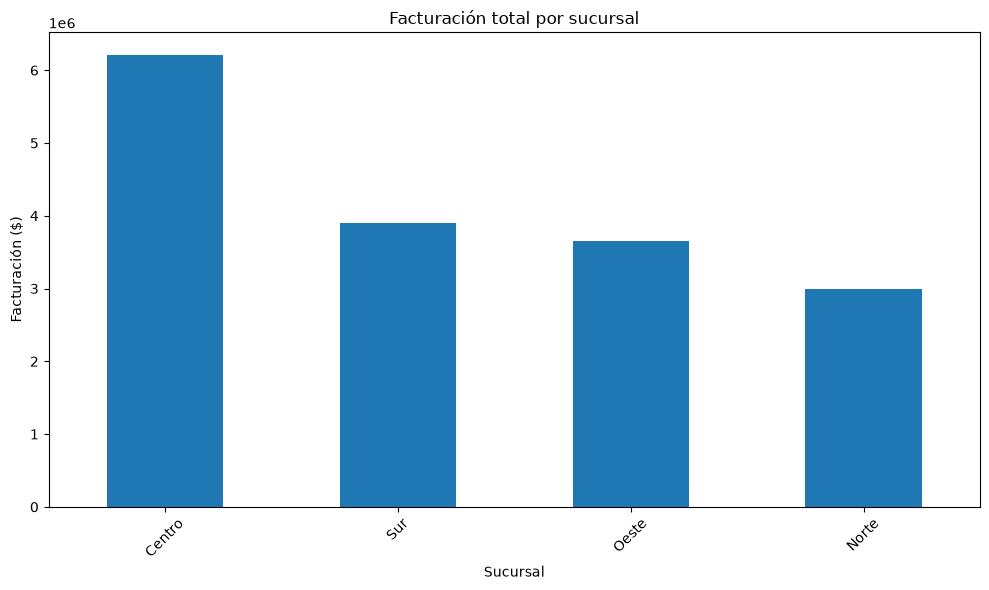

In [39]:
print("\n--- GRÁFICO 1: FACTURACIÓN POR SUCURSAL ---")

# Agrupamos la facturación total por sucursal
facturacion_sucursal = df.groupby("Sucursal")["Importe_Final"].sum()

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))

facturacion_sucursal.sort_values(ascending=False).plot(
    kind="bar"
)

# Título y etiquetas
plt.title("Facturación total por sucursal")
plt.xlabel("Sucursal")
plt.ylabel("Facturación ($)")

# Ajustamos la escala y las etiquetas
plt.xticks(rotation=45)
plt.tight_layout()

# Mostramos el gráfico
plt.show()


--- GRÁFICO 2: UNIDADES VENDIDAS POR CATEGORÍA ---


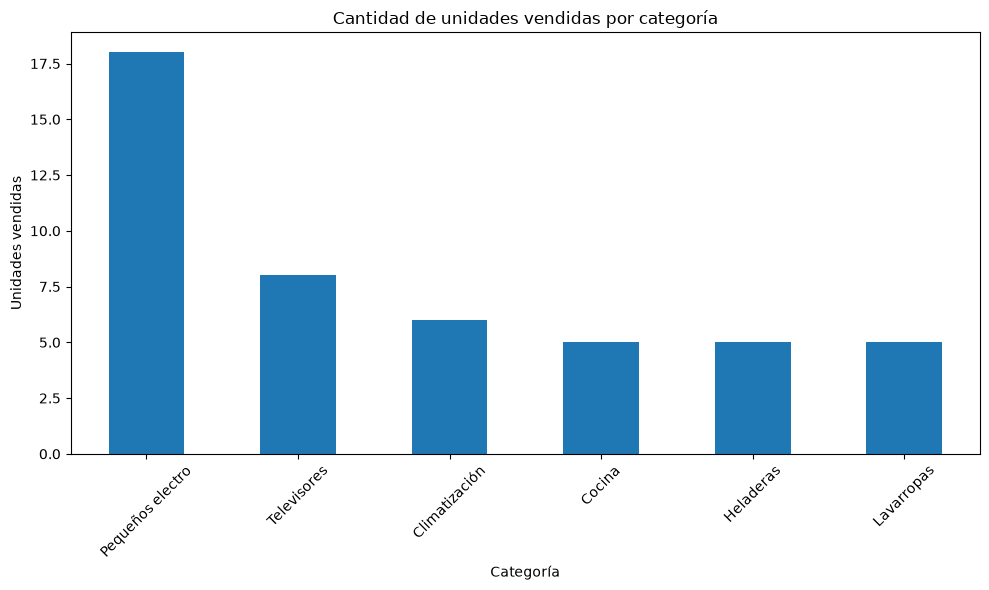

In [40]:
print("\n--- GRÁFICO 2: UNIDADES VENDIDAS POR CATEGORÍA ---")

# Sumamos las unidades vendidas por categoría
unidades_categoria = df.groupby("Categoria")["Cantidad"].sum()

# Creamos el gráfico
plt.figure(figsize=(10, 6))

unidades_categoria.sort_values(ascending=False).plot(
    kind="bar"
)

# Título y etiquetas
plt.title("Cantidad de unidades vendidas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Unidades vendidas")

# Ajustamos las etiquetas
plt.xticks(rotation=45)
plt.tight_layout()

# Mostramos el gráfico
plt.show()


--- GRÁFICO 3: DISTRIBUCIÓN DEL IMPORTE POR CANAL ---


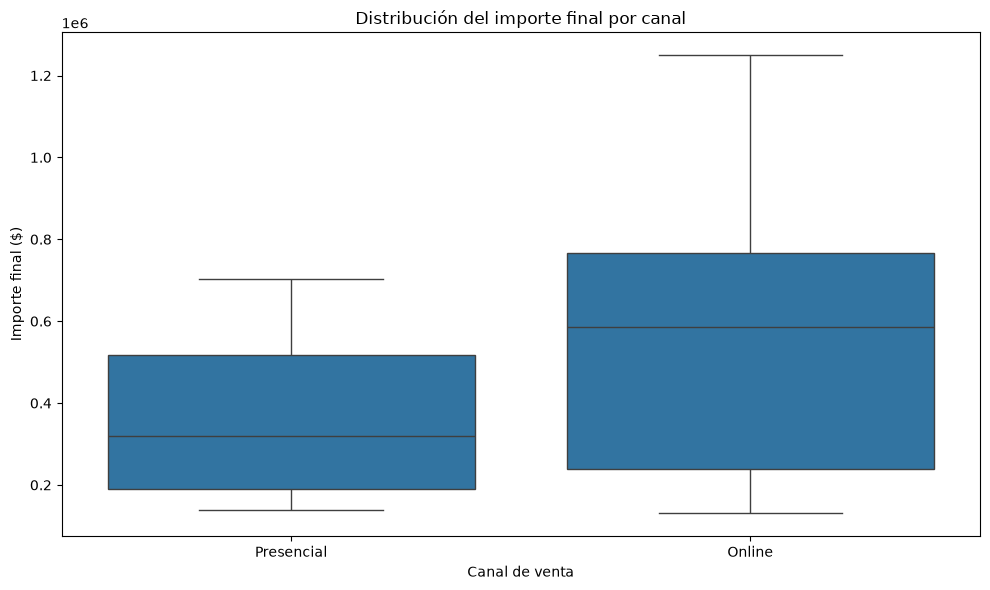

In [41]:
print("\n--- GRÁFICO 3: DISTRIBUCIÓN DEL IMPORTE POR CANAL ---")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Canal",
    y="Importe_Final"
)

# Título y etiquetas
plt.title("Distribución del importe final por canal")
plt.xlabel("Canal de venta")
plt.ylabel("Importe final ($)")

plt.tight_layout()

# Mostramos el gráfico
plt.show()


--- GRÁFICO 4: PRECIO UNITARIO Y CANTIDAD ---


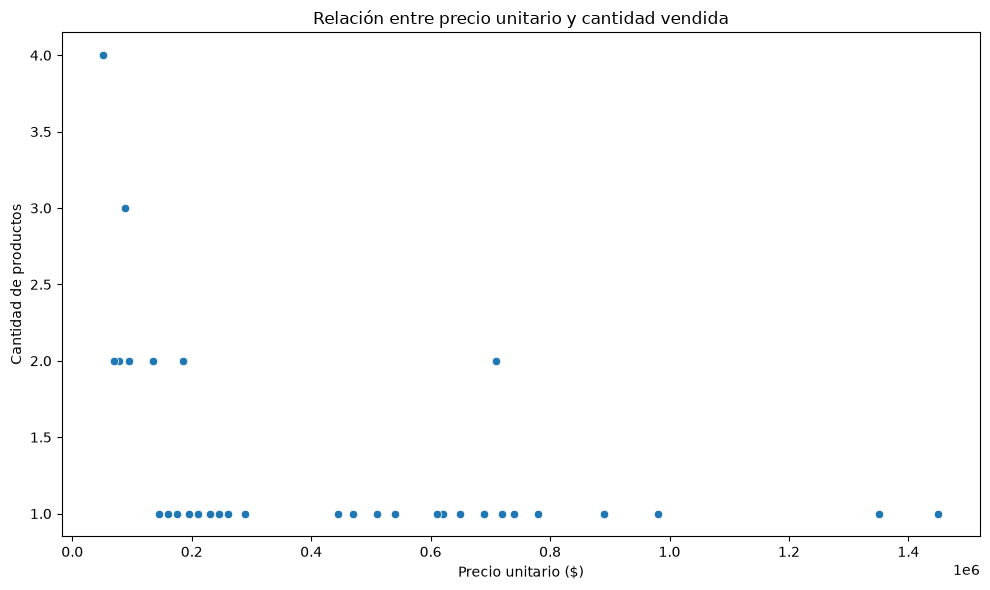

In [42]:
print("\n--- GRÁFICO 4: PRECIO UNITARIO Y CANTIDAD ---")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Precio_Unitario",
    y="Cantidad"
)

# Título y etiquetas
plt.title("Relación entre precio unitario y cantidad vendida")
plt.xlabel("Precio unitario ($)")
plt.ylabel("Cantidad de productos")

plt.tight_layout()

# Mostramos el gráfico
plt.show()

# ARCHIVO PREPARADO PARA EXCEL O POWER BI

In [43]:
with pd.ExcelWriter(
    "ventas_electrodomesticos_preparados.xlsx", engine="openpyxl"
) as writer:
    #HOJA PRINCIPAL CON LOS DATOS PREPARADOS.

    df.to_excel(
        writer, sheet_name="Datos_Preparados", index=False
    )

    # RESUMEN POR SUCURSAL

    resumen_sucursal = df.groupby("Sucursal").agg(
        Operaciones=("ID_Venta", "count"), Facturacio=("Importe_Final", "sum"), Importe_Promedio=("Importe_Final", "mean")
    ).reset_index()

    resumen_sucursal.to_excel(
        writer, sheet_name="Resumen_Sucursal", index=False
    )

    # RESUMEN POR CANAL

    resumen_canal = df.groupby("Canal").agg(
        Operaciones=("ID_Venta", "count"), Facturacion=("Importe_Final", "sum"), Importe_Promedio=("Importe_Final", "mean")
    ).reset_index()

    resumen_canal.to_excel(
        writer, sheet_name="Resumen_Canal", index=False
    )

print("Archivo Excel con varias hojas creado correctamente.")

Archivo Excel con varias hojas creado correctamente.


In [44]:
# AJUSTE AUTOMÁTICO PARA EL ANCHO DE COLUMNAS

from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

print("\n--- AJUSTE AUTOMÁTICO DEL ANCHO DE COLUMNAS ---")

archivo = "ventas_electrodomesticos_preparados.xlsx"

libro = load_workbook(archivo)

for hoja in libro.worksheets:

    for columna in hoja.iter_cols():
        ancho_maximo = 0
        letra_columna = get_column_letter(columna[0].column)

        for celda in columna:
            if celda.value is not None:
                longitud = len(str(celda.value))
                if longitud > ancho_maximo:
                    ancho_maximo = longitud

        ancho_ajustado = ancho_maximo + 2
        hoja.column_dimensions[letra_columna].width = ancho_ajustado

libro.save(archivo)

print("Ancho de todas las columnas ajustado correctamente.")
print("Archivo actualizado:", archivo)


--- AJUSTE AUTOMÁTICO DEL ANCHO DE COLUMNAS ---
Ancho de todas las columnas ajustado correctamente.
Archivo actualizado: ventas_electrodomesticos_preparados.xlsx
